# K06_02_GridSearchCV_fuer_Entscheidungsbaeume

Update am 27. Mai 2026

# Hyperparameter Suche mit `**GridSearchCV**`

# Bibliotheken und Daten laden

## Der Breast Cancer Datensatz

Ein klassischer ML-Datensatz aus der medizinischen Diagnostik, der in scikit-learn direkt eingebaut ist:

```python
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
```

---

### Was steckt drin?

| Eigenschaft | Wert |
|---|---|
| Datenpunkte | 569 Tumorproben |
| Features | 30 numerische Merkmale |
| Klassen | 2 (binär) |
| Klasse 0 | malignant – bösartig (212 Fälle) |
| Klasse 1 | benign – gutartig (357 Fälle) |

---

### Woher kommen die Daten?

Jede Zeile ist eine **Gewebeprobe** eines Brusttumors. Ein Arzt hat Zellen unter dem Mikroskop vermessen. Die 30 Features beschreiben die Geometrie der Zellkerne, z. B.:

- `mean radius` – durchschnittlicher Radius der Zellen
- `mean texture` – Oberflächenstruktur
- `mean concavity` – Einbuchtungen am Zellrand
- `mean symmetry` – Symmetrie der Zellen

---

### Die Aufgabe für das Modell

```
30 Messwerte einer Probe  →  Modell  →  bösartig oder gutartig?
```

Das ist ein **binäres Klassifikationsproblem** — genau das, wofür logistische Regression und Entscheidungsbäume ideal sind.

---


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Daten laden
X, y = load_breast_cancer(return_X_y=True)
X.shape, y.shape

((569, 30), (569,))

In [2]:
import time

# Startzeit für das gesamte Notebook
t_notebook_start = time.time()
print("Notebook-Laufzeitmessung gestartet.")


Notebook-Laufzeitmessung gestartet.


# Trainings- und Testdaten erstellen

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Classifier für Entscheidungsbäume erstellen und evaluieren (im Default)

In [4]:
tree_clf_default = DecisionTreeClassifier(random_state=42)
tree_clf_default.fit(X_train, y_train)

y_pred_default = tree_clf_default.predict(X_test)
acc_baseline = accuracy_score(y_test, y_pred_default)

print(f"Baseline-Accuracy (Default-Baum): {acc_baseline:.4f}")
print(f"Baumtiefe: {tree_clf_default.get_depth()}, "
      f"Blaetter: {tree_clf_default.get_n_leaves()}")
print()
print("Hinweis: Der Default-Baum hat keine Tiefenbegrenzung")
print("-> er overfittet auf den Trainingsdaten.")
print("GridSearchCV sucht nun reguliertere Varianten.")


Baseline-Accuracy (Default-Baum): 0.9123
Baumtiefe: 7, Blaetter: 19

Hinweis: Der Default-Baum hat keine Tiefenbegrenzung
-> er overfittet auf den Trainingsdaten.
GridSearchCV sucht nun reguliertere Varianten.


# `GridSeachCV` durchführen und evaluieren


## Die Parameter des `param_grid` erklärt

Alle vier Parameter steuern, wie groß und komplex der Entscheidungsbaum werden darf.

---

### `max_depth` – Maximale Tiefe des Baums

Wie viele Ebenen darf der Baum haben?

```
max_depth=2:          max_depth=4:
      [A]                   [A]
     /   \                 /   \
   [B]   [C]            [B]   [C]
   (fertig)            /   \   /  \
                     [D][E][F][G]
                     / \ ...
                  (noch tiefer)
```

Ein tiefer Baum lernt sehr spezifische Regeln → Gefahr: Overfitting.
Ein flacher Baum lernt nur grobe Regeln → Gefahr: Underfitting.

---

### `max_leaf_nodes` – Maximale Anzahl Blätter

Blätter sind die **Endknoten** des Baums — dort wird die finale Klasse ausgegeben. Dieser Parameter begrenzt direkt, wie viele verschiedene Entscheidungen der Baum treffen kann:

```
max_leaf_nodes=2:  nur 2 mögliche Endergebnisse  →  sehr einfach
max_leaf_nodes=9:  bis zu 9 mögliche Endergebnisse →  differenzierter
```

Wirkt ähnlich wie `max_depth`, aber direkter — man begrenzt die Blätter, nicht die Ebenen.

---

### `min_samples_split` – Mindestgröße zum Aufteilen

Wie viele Datenpunkte müssen in einem Knoten liegen, damit er **überhaupt aufgeteilt** werden darf?

```
min_samples_split=2:   schon ab 2 Punkten wird aufgeteilt  →  Baum wird sehr fein
min_samples_split=20:  erst ab 20 Punkten wird aufgeteilt  →  Baum bleibt grober
```

Kleine Werte → der Baum teilt auch winzige Gruppen noch weiter auf → Overfitting-Risiko.  
Große Werte → der Baum hört früher auf zu teilen → robustere, allgemeinere Regeln.

---

### `min_samples_leaf` – Mindestgröße eines Blatts

Wie viele Datenpunkte muss ein **Endknoten (Blatt) mindestens** enthalten?

```
min_samples_leaf=1:   ein Blatt darf für nur 1 Datenpunkt existieren  →  sehr speziell
min_samples_leaf=10:  ein Blatt muss mindestens 10 Punkte repräsentieren →  stabiler
```

Das verhindert, dass der Baum einzelne Ausreißer als eigene Regel lernt.

---

### Zusammenfassung

| Parameter | Steuert | Kleiner Wert | Großer Wert |
|---|---|---|---|
| `max_depth` | Tiefe des Baums | komplex, Overfitting | einfach, Underfitting |
| `max_leaf_nodes` | Anzahl Endknoten | wenig Entscheidungen | mehr Entscheidungen |
| `min_samples_split` | Wann wird geteilt? | feiner, komplexer | grober, robuster |
| `min_samples_leaf` | Mindestgröße Blatt | speziell, instabil | allgemein, stabil |

> **Merksatz:** Alle vier Parameter sind **Komplexitätsbremsen**. GridSearchCV probiert alle Kombinationen durch und findet heraus, welche Bremskombination den besten Score auf den Testdaten liefert.

In [5]:
# Hyperparameter-Gitter
param_grid = {
    'max_leaf_nodes':    list(range(2, 10)),   # 8 Werte
    'max_depth':         list(range(1, 10)),   # 9 Werte
    'min_samples_split': [2, 5, 10, 20],       # 4 Werte
    'min_samples_leaf':  [1, 2, 5, 10]         # 4 Werte
}  # -> 8 x 9 x 4 x 4 = 1152 Kombinationen x cv=5 = 5760 Trainingslaeufe

n_combinations = (len(param_grid['max_leaf_nodes']) *
                  len(param_grid['max_depth']) *
                  len(param_grid['min_samples_split']) *
                  len(param_grid['min_samples_leaf']))
print(f"Parameterkombinationen: {n_combinations}")
print(f"Trainingslaeufe gesamt: {n_combinations * 5}")
print()

# GridSearchCV
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              # 5-fache Kreuzvalidierung pro Kombination
    scoring='accuracy',
    n_jobs=-1          # alle CPU-Kerne nutzen
)

# ── Laufzeitmessung GridSearchCV ─────────────────────────────────────────
t_grid_start = time.time()

grid.fit(X_train, y_train)

t_grid_end = time.time()
t_grid = t_grid_end - t_grid_start
print(f"GridSearchCV Laufzeit: {t_grid:.2f} s  "
      f"({t_grid / n_combinations * 1000:.2f} ms pro Kombination)")
print()
# ─────────────────────────────────────────────────────────────────────────

print('Beste Parameter:')
print(grid.best_params_)
print()
print(f'Bester CV-Score (leicht optimistisch): {grid.best_score_:.4f}')
print()
print('Hinweis: Dieser CV-Score ist leicht optimistisch (Selection Bias).')
print('Er wurde genutzt, um die Parameter zu WAEHLEN.')
print('Der ehrliche Score folgt auf den unberührten Testdaten.')


Parameterkombinationen: 1152
Trainingslaeufe gesamt: 5760

GridSearchCV Laufzeit: 45.51 s  (39.51 ms pro Kombination)

Beste Parameter:
{'max_depth': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Bester CV-Score (leicht optimistisch): 0.9363

Hinweis: Dieser CV-Score ist leicht optimistisch (Selection Bias).
Er wurde genutzt, um die Parameter zu WAEHLEN.
Der ehrliche Score folgt auf den unberührten Testdaten.


# Beste Hyperparameter auf Testdaten evaluieren

In [6]:
# best_estimator_: das fertig trainierte Modell mit den besten Parametern
# GridSearchCV hat es automatisch auf allen X_train neu trainiert
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print('Bester Baum (GridSearchCV):')
print(f'  Tiefe:    {best_model.get_depth()}')
print(f'  Blaetter: {best_model.get_n_leaves()}')
print()
print(f'CV-Score (leicht optimistisch): {grid.best_score_:.4f}')
print(f'Test-Accuracy bestes Modell:    {acc_best:.4f}  <- ehrliche Schaetzung')
print(f'Test-Accuracy Baseline:         {acc_baseline:.4f}')
print()
gewinn = acc_best - acc_baseline
if gewinn > 0:
    print(f'GridSearch verbessert die Baseline um {gewinn:.4f} '
          f'({gewinn/acc_baseline*100:.1f}% relativer Gewinn)')
elif gewinn == 0:
    print('GridSearch liefert dasselbe Ergebnis wie die Baseline.')
    print('(Auf kleinen Datensaetzen kann das vorkommen)')
else:
    print(f'Baseline liegt knapp vorn ({abs(gewinn):.4f} Differenz).')


Bester Baum (GridSearchCV):
  Tiefe:    3
  Blaetter: 5

CV-Score (leicht optimistisch): 0.9363
Test-Accuracy bestes Modell:    0.9386  <- ehrliche Schaetzung
Test-Accuracy Baseline:         0.9123

GridSearch verbessert die Baseline um 0.0263 (2.9% relativer Gewinn)


## Feature Importance des besten Baums

GridSearchCV hat den optimalen Baum gefunden. Jetzt schauen wir,
welche der 30 Breast-Cancer-Features er als besonders wichtig eingestuft hat.

Feature Importance funktioniert genauso wie beim Iris-Baum -- nur mit mehr Features.


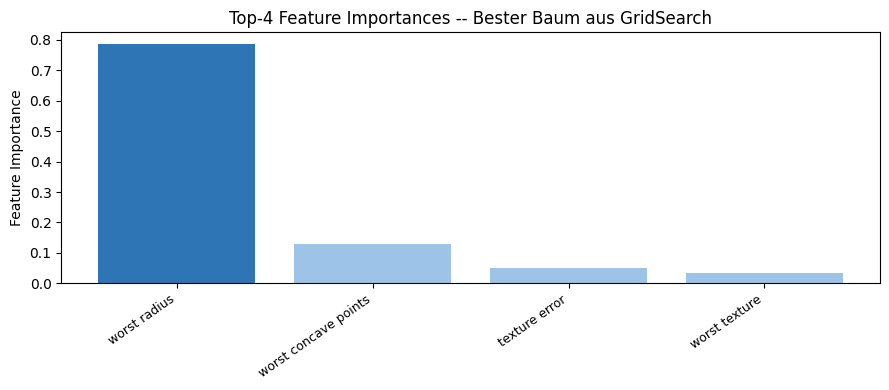

Beobachtung:
Ein regulierter Baum nutzt nur wenige Features.
Die wichtigsten entscheiden den Grossteil der Klassifikation.


In [7]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer
feature_names = load_breast_cancer().feature_names

importances = best_model.feature_importances_

# Nur die Top-10 Features zeigen (die anderen sind 0 beim regulierten Baum)
indices = np.argsort(importances)[::-1]
top_n = min(10, (importances > 0).sum())  # nur Features mit Importance > 0

plt.figure(figsize=(9, 4))
plt.bar(
    range(top_n),
    importances[indices[:top_n]],
    color=['#2E75B6' if i == 0 else '#9DC3E6' for i in range(top_n)]
)
plt.xticks(range(top_n),
           [feature_names[i] for i in indices[:top_n]],
           rotation=35, ha='right', fontsize=9)
plt.ylabel('Feature Importance')
plt.title(f'Top-{top_n} Feature Importances -- Bester Baum aus GridSearch')
plt.tight_layout()
plt.show()

print('Beobachtung:')
print('Ein regulierter Baum nutzt nur wenige Features.')
print('Die wichtigsten entscheiden den Grossteil der Klassifikation.')


In [8]:
# Gesamt-Laufzeit des Notebooks
t_notebook_end = time.time()
t_gesamt = t_notebook_end - t_notebook_start

print("=" * 45)
print("Laufzeit-Zusammenfassung")
print("=" * 45)
print(f"  GridSearchCV:       {t_grid:>7.2f} s")
print(f"  Restliches Notebook:{t_gesamt - t_grid:>7.2f} s")
print(f"  Gesamt:             {t_gesamt:>7.2f} s")
print("=" * 45)
print(f"  {n_combinations * 5} Trainingslaeufe in {t_grid:.1f} s")
print(f"  -> {t_grid / (n_combinations * 5) * 1000:.2f} ms pro Trainingslauf")


Laufzeit-Zusammenfassung
  GridSearchCV:         45.51 s
  Restliches Notebook:  45.49 s
  Gesamt:               91.01 s
  5760 Trainingslaeufe in 45.5 s
  -> 7.90 ms pro Trainingslauf
